<a href="https://colab.research.google.com/github/BigBisus/LeonovLabs/blob/master/leonov_lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install tensorflow -q

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Embedding,
    GRU,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [23]:
print("GPU devices:")
print(tf.config.list_physical_devices('GPU'))

GPU devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [24]:
max_features = 10001

maxlen = 500

embedding_dim = 64

gru_units = 128

batch_size = 128

epochs = 35

In [25]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=max_features
)

print("Размер обучающей выборки:", len(x_train))
print("Размер тестовой выборки:", len(x_test))

Размер обучающей выборки: 25000
Размер тестовой выборки: 25000


In [26]:
x_train = pad_sequences(
    x_train,
    maxlen=maxlen
)

x_test = pad_sequences(
    x_test,
    maxlen=maxlen
)

print("Форма x_train:", x_train.shape)
print("Форма x_test:", x_test.shape)

Форма x_train: (25000, 500)
Форма x_test: (25000, 500)


In [27]:
model_gru = Sequential()

model_gru.add(
    Embedding(
        input_dim=max_features,
        output_dim=embedding_dim
    )
)

model_gru.add(
    GRU(
        gru_units,
        dropout=0.2
    )
)

model_gru.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model_gru.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
model_gru.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_gru = model_gru.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2
)

Epoch 1/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.6283 - loss: 0.6307 - val_accuracy: 0.7568 - val_loss: 0.5046
Epoch 2/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.7901 - loss: 0.4528 - val_accuracy: 0.8392 - val_loss: 0.4168
Epoch 3/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8229 - loss: 0.3991 - val_accuracy: 0.8218 - val_loss: 0.3920
Epoch 4/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8479 - loss: 0.3596 - val_accuracy: 0.8312 - val_loss: 0.3803
Epoch 5/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8687 - loss: 0.3186 - val_accuracy: 0.8444 - val_loss: 0.3963
Epoch 6/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8753 - loss: 0.3040 - val_accuracy: 0.8344 - val_loss: 0.3768
Epoch 7/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8839 - loss: 0.2841 - val_accuracy: 0.8738 - val_loss: 0.3152
Epoch 8/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.8953 - loss: 0.2637 - val_ac

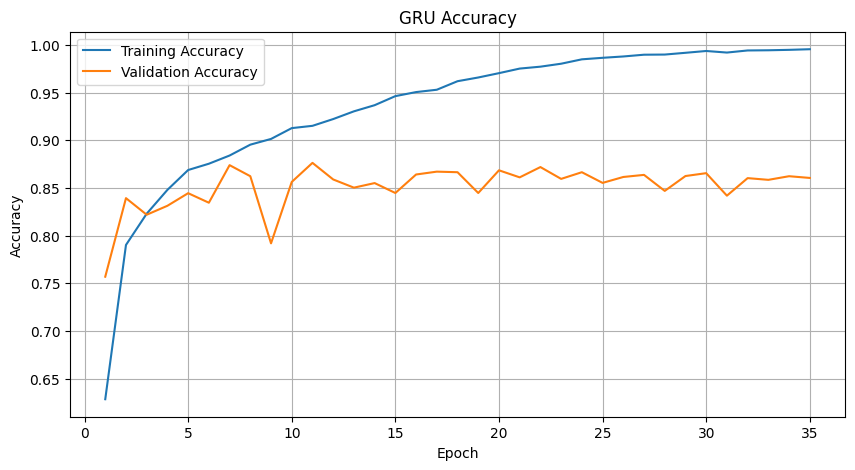

In [29]:
acc = history_gru.history['accuracy']
val_acc = history_gru.history['val_accuracy']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(10,5))

plt.plot(
    epochs_range,
    acc,
    label='Training Accuracy'
)

plt.plot(
    epochs_range,
    val_acc,
    label='Validation Accuracy'
)

plt.title('GRU Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid()

plt.show()

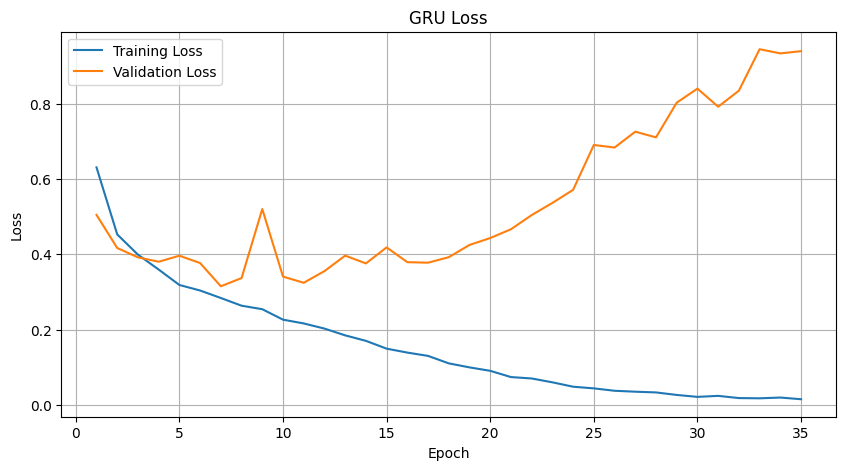

In [30]:
loss = history_gru.history['loss']
val_loss = history_gru.history['val_loss']

plt.figure(figsize=(10,5))

plt.plot(
    epochs_range,
    loss,
    label='Training Loss'
)

plt.plot(
    epochs_range,
    val_loss,
    label='Validation Loss'
)

plt.title('GRU Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid()

plt.show()

In [31]:
test_loss, test_acc = model_gru.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8593 - loss: 0.9636
Test Accuracy: 0.8593199849128723
Test Loss: 0.9635629057884216


In [32]:
predictions = model_gru.predict(x_test[:10])

for i in range(10):

    print(f"\nОтзыв {i+1}")

    print("Вероятность положительного отзыва:",
          predictions[i][0])

    if predictions[i][0] > 0.5:
        print("Положительный отзыв")
    else:
        print("Отрицательный отзыв")

    print("Правильный ответ:", y_test[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step

Отзыв 1
Вероятность положительного отзыва: 0.0476
Отрицательный отзыв
Правильный ответ: 0

Отзыв 2
Вероятность положительного отзыва: 1.0
Положительный отзыв
Правильный ответ: 1

Отзыв 3
Вероятность положительного отзыва: 0.0
Отрицательный отзыв
Правильный ответ: 1

Отзыв 4
Вероятность положительного отзыва: 1.0
Положительный отзыв
Правильный ответ: 0

Отзыв 5
Вероятность положительного отзыва: 1.0
Положительный отзыв
Правильный ответ: 1

Отзыв 6
Вероятность положительного отзыва: 0.151
Отрицательный отзыв
Правильный ответ: 1

Отзыв 7
Вероятность положительного отзыва: 1.0
Положительный отзыв
Правильный ответ: 1

Отзыв 8
Вероятность положительного отзыва: 0.0
Отрицательный отзыв
Правильный ответ: 0

Отзыв 9
Вероятность положительного отзыва: 1.0
Положительный отзыв
Правильный ответ: 0

Отзыв 10
Вероятность положительного отзыва: 1.0
Положительный отзыв
Правильный ответ: 1


In [33]:
model_conv = Sequential()

model_conv.add(
    Embedding(
        input_dim=max_features,
        output_dim=embedding_dim,
        input_length=maxlen
    )
)

model_conv.add(
    Conv1D(
        32,
        7,
        activation='relu'
    )
)

model_conv.add(
    MaxPooling1D(5)
)

model_conv.add(
    Conv1D(
        32,
        7,
        activation='relu'
    )
)

model_conv.add(
    MaxPooling1D(5)
)

model_conv.add(
    Conv1D(
        32,
        7,
        activation='relu'
    )
)

model_conv.add(
    GlobalMaxPooling1D()
)

model_conv.add(
    Dense(1, activation='sigmoid')
)

model_conv.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
model_conv.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [35]:
history_conv = model_conv.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2
)

Epoch 1/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 67s 372ms/step - accuracy: 0.5883 - loss: 0.6712 - val_accuracy: 0.7400 - val_loss: 0.5313
Epoch 2/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.8032 - loss: 0.4324 - val_accuracy: 0.8300 - val_loss: 0.3928
Epoch 3/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8606 - loss: 0.3299 - val_accuracy: 0.8582 - val_loss: 0.3394
Epoch 4/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8929 - loss: 0.2661 - val_accuracy: 0.8666 - val_loss: 0.3197
Epoch 5/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9128 - loss: 0.2236 - val_accuracy: 0.8706 - val_loss: 0.3211
Epoch 6/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9324 - loss: 0.1791 - val_accuracy: 0.8524 - val_loss: 0.4272
Epoch 7/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9474 - loss: 0.1441 - val_accuracy: 0.8642 - val_loss: 0.3855
Epoch 8/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9657 - loss: 0.0998 - val_ac

In [36]:
conv_loss, conv_acc = model_conv.evaluate(
    x_test,
    y_test
)

print("Conv1D Accuracy:", conv_acc)
print("Conv1D Loss:", conv_loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8589 - loss: 1.3168
Conv1D Accuracy: 0.8589199781417847
Conv1D Loss: 1.3168343305587769


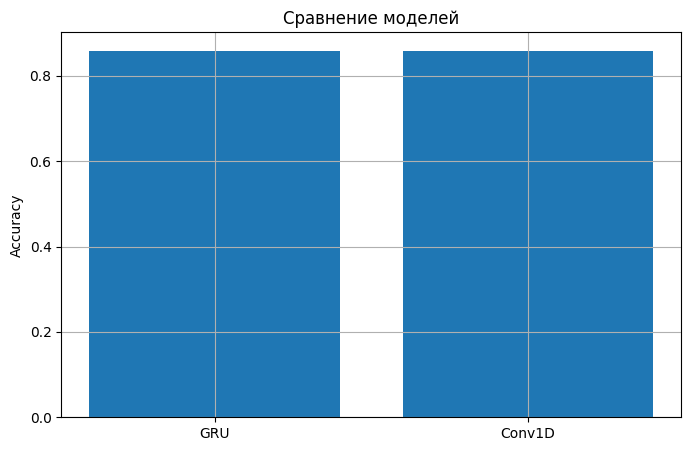

In [37]:
models = ['GRU', 'Conv1D']
accuracies = [test_acc, conv_acc]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title('Сравнение моделей')
plt.ylabel('Accuracy')

plt.grid()

plt.show()

In [38]:
print("Точность GRU модели:", test_acc)
print("Точность Conv1D модели:", conv_acc)

if test_acc > conv_acc:
    print("\nGRU показала лучший результат.")
else:
    print("\nConv1D показала лучший результат.")

Точность GRU модели: 0.8593199849128723
Точность Conv1D модели: 0.8589199781417847

GRU показала лучший результат.
